# Data Understanding (Pengambilan dan Eksplorasi Data NO<sub>2</sub> Di Kabupaten Bangkalan)

In [1]:
!pip install openeo

**Penjelasan:** Menginstal library openeo yang diperlukan untuk mengakses data satelit dari Copernicus Data Space Ecosystem. OpenEO adalah API standar untuk mengakses data Earth Observation secara cloud-based.

In [2]:
import openeo
import pandas as pd
import matplotlib.pyplot as plt

**Penjelasan:**
- openeo: Untuk koneksi ke layanan data satelit
- pandas: Untuk manipulasi dan analisis data
- matplotlib.pyplot: Untuk visualisasi data

## **Koneksi ke Copernicus Data Space**

In [3]:
# 1. Koneksi ke Copernicus Data Space
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


**Penjelasan:** Membuat koneksi ke server Copernicus Data Space menggunakan autentikasi OIDC (OpenID Connect).

## **Koordinat Daerah Bangkalan**

Disini saya menggunakan koordinat bangkalan yang dimana koordinat ini di dapat melalui Website geojson geojson.io

In [4]:
# 2. AOI
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.66348800282009, -7.007389234733083],
            [112.66348800282009, -7.179646382822568],
            [112.97492116433409, -7.179646382822568],
            [112.97492116433409, -7.007389234733083],
            [112.66348800282009, -7.007389234733083],
        ]
    ],
}


**Penjelasan:** Mendefinisikan Area of Interest (AOI) dalam format GeoJSON polygon yang mencakup wilayah Kabupaten Bangkalan.

In [5]:
s5p = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent={
        "west": 112.66348800282009,
        "south": -7.179646382822568,
        "east": 112.97492116433409,
        "north": -7.007389234733083,
    },
    temporal_extent=["2025-01-01", "2025-10-01"],
    bands=["NO2"],
)


**Penjelasan:**
- Memuat koleksi data Sentinel-5P Level 2
- spatial_extent: Membatasi data sesuai koordinat Bangkalan
- temporal_extent: Periode data dari 1 Januari 2025 - 1 Oktober 2025
- bands: Hanya mengambil band NO₂ (nitrogen dioksida)

## **Pengambilan Data NO<sub>2</sub>**

In [6]:
# 4. Mask nilai negatif (data invalid)
def mask_invalid(x):
    return x < 0

s5p_masked = s5p.mask(s5p.apply(mask_invalid))

# 5. Agregasi temporal harian
daily_mean = s5p_masked.aggregate_temporal_period(period="day", reducer="mean")

# 6. Agregasi spasial (rata-rata dalam AOI)
daily_mean_aoi = daily_mean.aggregate_spatial(geometries=aoi, reducer="mean")

# 7. Jalankan batch job dan hasilkan file CSV
job = daily_mean_aoi.execute_batch(out_format="CSV",)

# 8. Unduh hasil job
results = job.get_results()
results.download_files("no2_results")


0:00:00 Job 'j-2511021434224ca7843214a86b1eedc6': send 'start'


0:00:13 Job 'j-2511021434224ca7843214a86b1eedc6': created (progress 0%)


0:00:18 Job 'j-2511021434224ca7843214a86b1eedc6': created (progress 0%)


0:00:25 Job 'j-2511021434224ca7843214a86b1eedc6': created (progress 0%)


**Penjelasan:**
- Masking: Menghilangkan nilai negatif yang merupakan data invalid
- Agregasi temporal: Menghitung rata-rata harian dari multiple pengukuran per hari
- Agregasi spasial: Menghitung rata-rata spasial dalam AOI Bangkalan
- Batch processing: Menjalankan pemrosesan di server dan mengunduh hasil dalam format CSV

In [35]:
import os
import shutil

old_name = "no2_results/timeseries.csv"
new_name = "no2_results/no2_bangkalan_data.csv"

if os.path.exists(old_name):
    shutil.move(old_name, new_name)
    print(f"File renamed from 'timeseries.csv' to 'no2_bangkalan_data.csv'")
else:
    print("File timeseries.csv not found")

File renamed from 'timeseries.csv' to 'no2_bangkalan_data.csv'


**Penjelasan:** Mengganti nama file default "timeseries.csv" menjadi "no2_bangkalan_data.csv" untuk penamaan yang lebih deskriptif.

In [36]:
# 9. Baca file CSV hasil
import os
df =pd.read_csv(os.path.join("no2_results", "no2_bangkalan_data.csv"))

In [37]:
# 10. Pastikan kolom tanggal benar
df["date"] = pd.to_datetime(df["date"])

# 11. Buat kolom bulan (YYYY-MM)
df["month"] = df["date"].dt.to_period("M")

# 12. Hitung rata-rata NO2 per bulan
df_monthly = df.groupby("month", as_index=False)["NO2"].mean()

df

C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_4676\3399061483.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


,date,feature_index,NO2,month
0,2025-02-26 00:00:00+00:00,0,NaN,2025-02
1,2025-03-02 00:00:00+00:00,0,0.000029,2025-03
2,2025-03-04 00:00:00+00:00,0,0.000033,2025-03
3,2025-02-25 00:00:00+00:00,0,0.000027,2025-02
4,2025-03-03 00:00:00+00:00,0,0.000026,2025-03
...,...,...,...,...
269,2025-09-15 00:00:00+00:00,0,0.000022,2025-09
270,2025-09-14 00:00:00+00:00,0,0.000017,2025-09
271,2025-09-19 00:00:00+00:00,0,0.000011,2025-09
272,2025-09-13 00:00:00+00:00,0,0.000026,2025-09


## **Mengecek Jumlah Missing Value**

In [38]:
NO2 = pd.read_csv('no2_results/no2_bangkalan_data.csv')
NO2 = NO2.sort_values(by='date')
NO2.isnull().sum()

date               0
feature_index      0
NO2              102
dtype: int64

In [39]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

,Missing Count,Missing Percent (%)
date,0,0.00
feature_index,0,0.00
NO2,102,37.23


C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_4676\3930139431.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


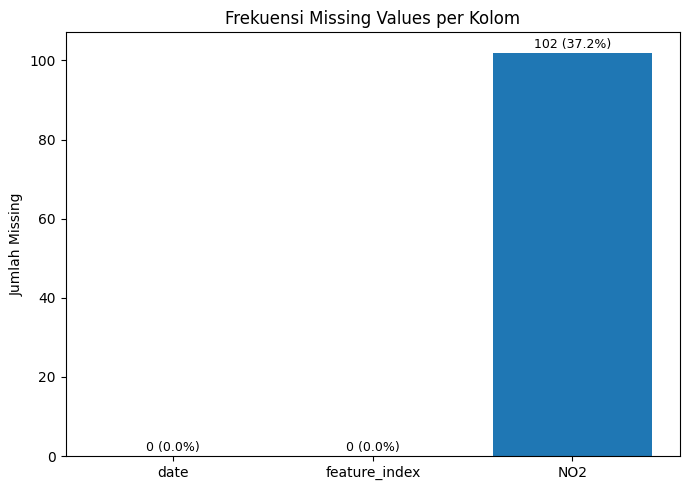

In [40]:
missing_count = NO2.isnull().sum()
missing_percent = (missing_count / len(NO2)) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(missing_count.index, missing_count)

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## **Mengecek Informasi Dataset**

In [41]:
NO2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, 200 to 192
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           274 non-null    object 
 1   feature_index  274 non-null    int64  
 2   NO2            172 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.6+ KB


## **Visualisasi Rata-Rata Kualitas Udara NO<sub>2</sub> Setiap Bulan di Bangkalan**

C:\Users\Harits Putra Junaidi\AppData\Local\Temp\ipykernel_4676\3279999190.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


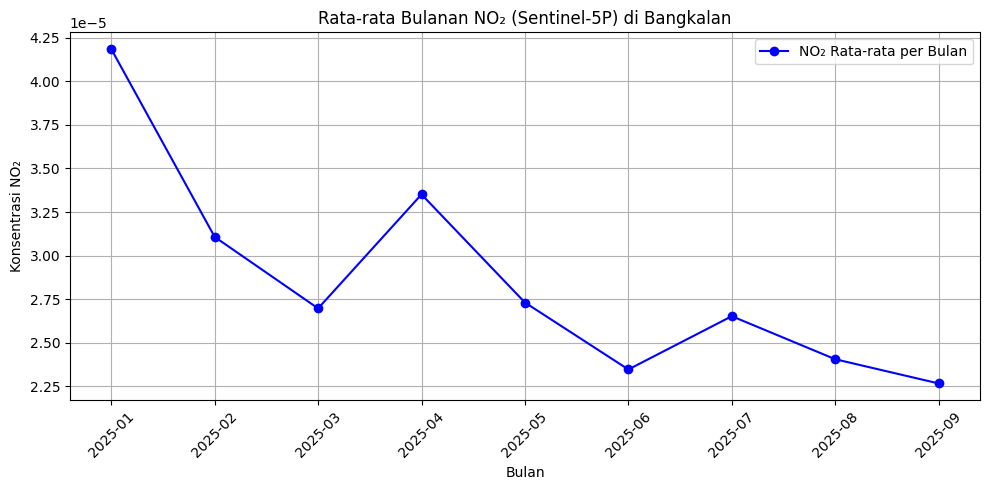

In [42]:
# Baca data
df = pd.read_csv("no2_results/no2_bangkalan_data.csv")

df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M")

df_monthly = df.groupby("month", as_index=False)["NO2"].mean()

# 13. Visualisasi hasil
plt.figure(figsize=(10,5))
plt.plot(df_monthly["month"].astype(str), df_monthly["NO2"], marker="o", color="blue", label="NO₂ Rata-rata per Bulan")
plt.title("Rata-rata Bulanan NO₂ (Sentinel-5P) di Bangkalan")
plt.xlabel("Bulan")
plt.ylabel("Konsentrasi NO₂")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()